In [1]:
# R script to identify and test for non-random occurrence of premature stop codon
# author: Sheng-Kai Hsu
# date created: 2023.08.01
# data last edited: 2024.07.11
# modified for panand GWAS

In [2]:
library(MSA2dist)
library(Biostrings)
library(parallel)
library(limma)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: XVector

Loading required package: GenomeInfoDb


Attaching package: ‘Biostrings’


The following object is masked from ‘package:b

In [32]:
aln.flist = list.files("/workdir/sh2246/p_phyloGWAS/output/CDSMSAPerOG_gs",full.names = T,
                       pattern = "*.gs.l0.fa$")
aln.list = mclapply(aln.flist,readDNAStringSet,mc.cores = 2)
names(aln.list) = substr(strsplit2(aln.flist,"/")[,7],1,9)

In [6]:
traitMat = read.csv("/workdir/sh2246/p_phyloGWAS/data/Perennitality_Numeric_Poaceae.csv",header = T)

rownames(traitMat) = traitMat$assemblyID

In [33]:
cont_tab_list = mclapply(aln.list,function(a){
    codonArray = sapply(a,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))
                        
    stopSite = unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)))
    if (any(stopSite<nrow(codonArray)*0.9)){idx = names(which(stopSite<nrow(codonArray)*0.9))
    } else idx = NULL

    annualPattern = paste(rownames(traitMat)[traitMat[,2]==1],collapse = "|")
    cont_tab = cbind(table(grepl(annualPattern,idx))[c("TRUE","FALSE")],
                     table(grepl(annualPattern,setdiff(colnames(codonArray),idx)))[c("TRUE","FALSE")])
    colnames(cont_tab) = c("TRUE","FALSE")
    rownames(cont_tab) = c("annual","perennial")
    cont_tab[is.na(cont_tab)] = 0
    return(cont_tab)                               
},mc.cores = 2)

In [34]:
cont_tab_list[[22]]

,TRUE,FALSE
annual,148,225
perennial,199,514


In [35]:
FET.p = mclapply(cont_tab_list,function(x) fisher.test(x)$p.value)
FET.or = mclapply(cont_tab_list,function(x) fisher.test(x)$estimate)                 

In [66]:
sum(p.adjust(FET.p,"bonferroni")<0.05&FET.or>2)
sum(p.adjust(FET.p,"bonferroni")<0.05&FET.or<0.5)
goi_more = names(which(p.adjust(FET.p,"bonferroni")<0.05&FET.or>2))
goi_less = names(which(p.adjust(FET.p,"bonferroni")<0.05&FET.or<.5))

[1] 568

[1] 342

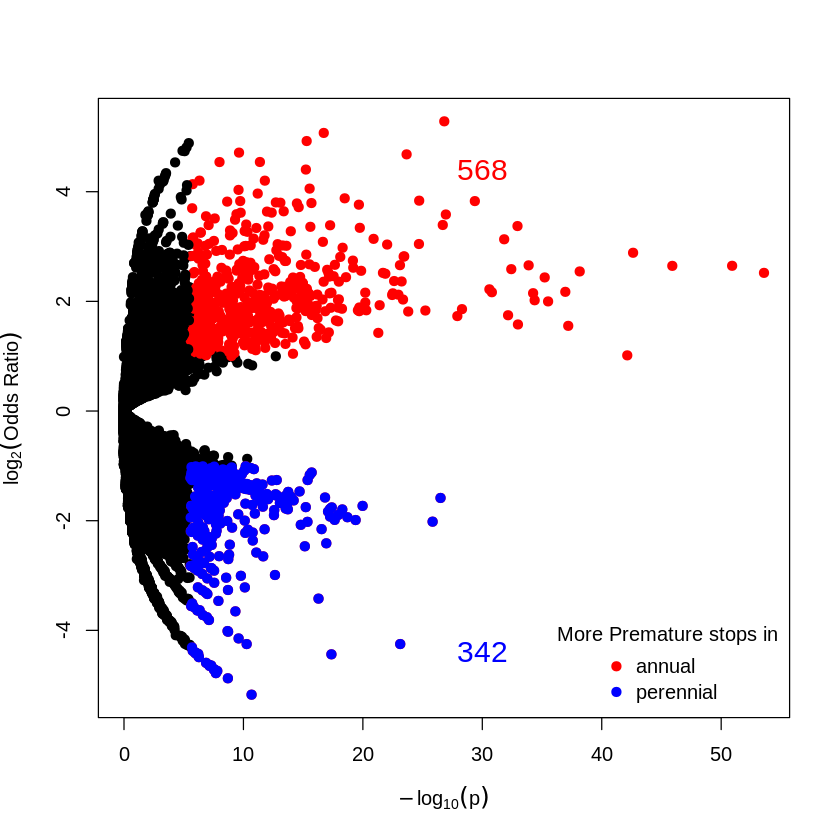

In [100]:
plot(-log10(as.numeric(FET.p)),log2(as.numeric(FET.or)),
     col =  ifelse(p.adjust(FET.p,"bonferroni")<0.05 & abs(log2(as.numeric(FET.or)))>1,"red","black"),
     xlab = expression(-log[10](p)),ylab = expression(log[2]("Odds Ratio")),pch = 19)
points(-log10(as.numeric(FET.p)),log2(as.numeric(FET.or)),
     col =  ifelse(p.adjust(FET.p,"bonferroni")<0.05 & log2(as.numeric(FET.or))< -1,"blue",NA),pch = 19)
text(30,4.4,labels = 568,col = "red",cex = 1.5)
text(30,-4.4,labels = 342, col = "blue",cex = 1.5)
legend("bottomright",pch = 19, col = c("red","blue"),legend = c("annual","perennial"),title = "More Premature stops in",bty = 'n')

In [101]:
png("/workdir/sh2246/p_phyloGWAS/output/prematureStop_volcano.png",width = 10,height = 10,units = "cm",pointsize = 8,res = 600)
plot(-log10(as.numeric(FET.p)),log2(as.numeric(FET.or)),
     col =  ifelse(p.adjust(FET.p,"bonferroni")<0.05 & abs(log2(as.numeric(FET.or)))>1,"red","black"),
     xlab = expression(-log[10](p)),ylab = expression(log[2]("Odds Ratio")),pch = 19)
points(-log10(as.numeric(FET.p)),log2(as.numeric(FET.or)),
     col =  ifelse(p.adjust(FET.p,"bonferroni")<0.05 & log2(as.numeric(FET.or))< -1,"blue",NA),pch = 19)
text(30,4.4,labels = 568,col = "red",cex = 1.5)
text(30,-4.4,labels = 342, col = "blue",cex = 1.5)
legend("bottomright",pch = 19, col = c("red","blue"),legend = c("annual","perennial"),title = "More Premature stops in",bty = 'n')
dev.off()

png 
  2

In [67]:
chisq.test(c(568,342),p = c(.5,.5))


	Chi-squared test for given probabilities

data:  c(568, 342)
X-squared = 56.127, df = 1, p-value = 6.792e-14


In [29]:
write.table(goi_more,"/workdir/sh2246/p_panAndOGASR/output/preStop_goi_more_v2.txt",quote = F,col.names = F,row.names = F)
write.table(goi_less,"/workdir/sh2246/p_panAndOGASR/output/preStop_goi_less_v2.txt",quote = F,col.names = F,row.names = F)

In [68]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping.txt")
sigHitsMore = mappingFile[mappingFile[,2]%in%goi_more,1]
sigHitsLess = mappingFile[mappingFile[,2]%in%goi_less,1]


In [74]:
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping.txt")
sigHitsMore = substr(mappingFile2[mappingFile2[,2]%in%goi_more,1],1,15)
sigHitsLess = substr(mappingFile2[mappingFile2[,2]%in%goi_less,1],1,15)

In [75]:
library(topGO)
# GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
# background = names(GODB)
# background = intersect(names(GODB),mappingFile[,1])
background = intersect(names(GODB),substr(mappingFile2[,1],1,15))

tmp=factor(as.integer(background%in%sigHitsMore))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table1=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)

tmp=factor(as.integer(background%in%sigHitsLess))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table2=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


Building most specific GOs .....

	( 3687 GO terms found. )


Build GO DAG topology ..........

	( 5258 GO terms and 11114 relations. )


Annotating nodes ...............

	( 12018 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 1377 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 1377 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 14:	2 nodes to be scored	(0 eliminated genes)


	 Level 13:	9 nodes to be scored	(0 eliminated genes)


	 Level 12:	28 nodes to be scored	(37 eliminated genes)


	 Level 11:	58 nodes to be scored	(208 eliminated genes)


	 Level 10:	103 nodes to be scored	(969 eliminated genes)


	 Level 9:	172 nodes to be scored	(2484 eliminated genes)


	 Level 8:	174 nodes to be scored	(3909 eliminated genes)


	 Level 7:	229 nodes to be scored	(5896 eliminated genes)


	 Level 6:	241 nodes to be scored	(7634 eliminated genes)


	

In [81]:
head(GO_res_table1,20)
head(GO_res_table2,20)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0006355,regulation of DNA-templated transcription,1497,95,50.70,4,4.8e-10,4.7e-08
2,GO:0010447,response to acidic pH,5,3,0.17,32,0.00037,0.00037
3,GO:0010044,response to aluminum ion,13,4,0.44,36,0.00073,0.00073
4,GO:0006357,regulation of transcription by RNA polymerase II,366,25,12.39,35,0.00069,0.00120
5,GO:0006334,nucleosome assembly,27,5,0.91,41,0.00189,0.00189
6,GO:0010468,regulation of gene expression,1885,118,63.84,1,3.6e-12,0.00266
7,GO:0010921,regulation of phosphatase activity,27,4,0.91,60,0.01227,0.00334
8,GO:0006952,defense response,739,31,25.03,211,0.12675,0.00439
9,GO:0048831,regulation of shoot system development,82,7,2.78,75,0.02091,0.00668


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0006075,(1->3)-beta-D-glucan biosynthetic process,8,4,0.16,1,9.7e-06,9.7e-06
2,GO:0008360,regulation of cell shape,21,4,0.41,3,0.00068,0.00068
3,GO:0006360,transcription by RNA polymerase I,10,3,0.20,4,0.00082,0.00082
4,GO:2000031,regulation of salicylic acid mediated signaling pathway,15,3,0.30,9,0.00289,0.00289
5,GO:0002100,tRNA wobble adenosine to inosine editing,5,2,0.10,12,0.00372,0.00372
6,GO:0009788,negative regulation of abscisic acid-activated signaling pathway,33,4,0.65,13,0.00385,0.00385
7,GO:0045053,protein retention in Golgi apparatus,6,2,0.12,19,0.00551,0.00551
8,GO:0000393,spliceosomal conformational changes to generate catalytic conformation,7,2,0.14,24,0.00762,0.00762
9,GO:0019375,galactolipid biosynthetic process,7,2,0.14,25,0.00762,0.00762


In [40]:
phyloP = read.table("/workdir/sh2246/p_panAndOGASR/output/phyloP_res_filtered_v2.txt",header = T)

bonferroni_cutoff = -log10(0.01/nrow(phyloP))
bonferroni_cutoff
goi_acc = phyloP[phyloP[,10] < -bonferroni_cutoff ,1]
goi_con = phyloP[phyloP[,10] > bonferroni_cutoff ,1]


[1] 5.946403

In [37]:
cont_table=function(query,background,classifyer){
  p1=length(intersect(query,classifyer))
  q1=length(query)-p1
  p0=length(setdiff(intersect(background,classifyer),intersect(query,classifyer)))
  q0=length(setdiff(background,query))-p0
  return(matrix(c(p1,p0,q1,q0),2,2))
}

In [41]:
fisher.test(cont_table(goi_acc,phyloP[,1],goi_more))
fisher.test(cont_table(goi_acc,phyloP[,1],goi_less))
fisher.test(cont_table(goi_con,phyloP[,1],goi_more))
fisher.test(cont_table(goi_con,phyloP[,1],goi_less))


	Fisher's Exact Test for Count Data

data:  cont_table(goi_acc, phyloP[, 1], goi_more)
p-value = 4.917e-10
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.681860 2.708821
sample estimates:
odds ratio 
   2.13673 



	Fisher's Exact Test for Count Data

data:  cont_table(goi_acc, phyloP[, 1], goi_less)
p-value = 0.002721
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.214313 2.602196
sample estimates:
odds ratio 
  1.785368 



	Fisher's Exact Test for Count Data

data:  cont_table(goi_con, phyloP[, 1], goi_more)
p-value = 0.2001
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8513956 1.8886048
sample estimates:
odds ratio 
  1.287946 



	Fisher's Exact Test for Count Data

data:  cont_table(goi_con, phyloP[, 1], goi_less)
p-value = 1.387e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 2.238943 5.464929
sample estimates:
odds ratio 
  3.545542 


In [42]:
cont_table(goi_acc,phyloP[,1],goi_more)
cont_table(goi_acc,phyloP[,1],goi_less)
cont_table(goi_con,phyloP[,1],goi_more)
cont_table(goi_con,phyloP[,1],goi_less)


130,2173
178,6358


48,2255
77,6459


31,682
277,7849


29,684
96,8030


In [101]:
# orthofinder CDS MSA
aln.flist = list.files("/workdir/sh2246/p_panAndOGASR/output/orthoFinderOGMSA_noSevir",full.names = T,
                       pattern = "*.gs.l0.fa$")
aln.list = mclapply(aln.flist,readDNAStringSet,mc.cores = 20)
names(aln.list) = substr(strsplit2(aln.flist,"/")[,7],1,9)

cont_tab_list = mclapply(aln.list,function(a){
    codonArray = sapply(a,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))
                        
    stopSite = na.omit(unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)[1])))
    if (any(stopSite<nrow(codonArray)*0.9)){idx = names(which(stopSite<nrow(codonArray)*0.9))
    } else idx = NULL

    annualPattern = "Zm|Zh|Zl|Zn|Zv|Zx|Sobic|Te"
    cont_tab = cbind(table(grepl(annualPattern,idx))[c("TRUE","FALSE")],
                     table(grepl(annualPattern,setdiff(colnames(codonArray),idx)))[c("TRUE","FALSE")])
    colnames(cont_tab) = c("TRUE","FALSE")
    rownames(cont_tab) = c("annual","perennial")
    cont_tab[is.na(cont_tab)] = 0
    return(cont_tab)                               
},mc.cores = 20)

In [5]:
# Premature stop matrix
pmStop_list = mclapply(aln.list,function(a){
    codonArray = sapply(a,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))
                        
    stopSite = na.omit(unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)[1])))
    if (any(stopSite<nrow(codonArray)*0.9)){idx = names(which(stopSite<nrow(codonArray)*0.9))
    } else idx = NULL

    return(idx)                               
},mc.cores = 20)

In [6]:
transTab = read.table("/workdir/sh2246/p_panAndOGASR/data/sixDigitCode2AnnotID",sep = "\t")
rownames(transTab) = transTab$V2


In [146]:
pmStopCountTab = simplify2array(mclapply(pmStop_list,function(x) {
    x = substr(x,2,8)
    x[grep("Pavag",x)] = "Pavag"
    x[grep("Sobic",x)] = "Sobic"
    x[grep("Seita",x)] = "Seita"
    x = transTab[x,1]
    return(table(x)[transTab[,1]])
},mc.cores = 30))

In [147]:
pmStopCountTab = t(pmStopCountTab)
pmStopCountTab[is.na(pmStopCountTab)]=0

colnames(pmStopCountTab) = transTab[,1]
head(pmStopCountTab)

,achine,agerar,atenui,avirgi,blagur,ccitra,crefra,cserru,etrips,hcompr,⋯,vcuspi,zdgigi,zdmomo,zmB735,zmhuet,znicar,zTIL01,zTIL11,zTIL18,zTIL25
OG0002048,0,0,0,0,0,0,0,2,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OG0002049,0,0,0,0,0,0,0,3,0,0,⋯,0,0,0,0,0,0,0,0,1,0
OG0002050,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,0
OG0002051,0,0,1,0,1,0,0,2,0,0,⋯,0,1,1,1,1,1,1,1,1,1
OG0002052,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OG0002054,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [148]:
write.table(pmStopCountTab,"/workdir/sh2246/p_panAndOGASR/output/prematureStopCodonCountTab_ogv9.2b.txt",col.names = T,row.names = T,sep = "\t",quote = F)

In [102]:
# ref_flist= list.files("/workdir/sh2246/p_panAndOGASR/output/ref_og",full.names = T)
# ref = mclapply(ref_flist,function(x) read.table(x,header = F)[,1],mc.cores = 20)
ref = mclapply(aln.list,function(x) {
    tmp = names(x)[grep("Pavag",names(x))]
    if (length(tmp)>1) tmp = sample(tmp,1)
    if (length(tmp)==0) tmp = NULL
    return(tmp)
})
head(ref)
length(ref)               

# names(cont_tab_list) = gsub(".gs.l0.fa","",strsplit2(aln.flist,"/")[,7])
names(cont_tab_list) = gsub("...p| ","",ref)

$OG0003381
[1] " Pavag09G110600.1.p"

$OG0003382
[1] " Pavag06G036500.1.p"

$OG0003384
[1] " Pavag03G170200.1.p"

$OG0003385
[1] " Pavag08G003900.1.p"

$OG0003386
[1] " Pavag02G368600.1.p"

$OG0003387
[1] " Pavag09G063200.1.p"

[1] 15780

In [103]:
FET.p = mclapply(cont_tab_list,function(x) fisher.test(x)$p.value,mc.cores = 20)
FET.or = mclapply(cont_tab_list,function(x) fisher.test(x)$estimate,mc.cores = 20)                 

sum(p.adjust(FET.p,"BH")<0.05&FET.or>1)
sum(p.adjust(FET.p,"BH")<0.05&FET.or<1)
goi_more = names(which(p.adjust(FET.p,"BH")<0.05&FET.or>1))
goi_less = names(which(p.adjust(FET.p,"BH")<0.05&FET.or<1))

[1] 82

[1] 9

In [104]:
chisq.test(c(82,9),p = c(.5,.5))


	Chi-squared test for given probabilities

data:  c(82, 9)
X-squared = 58.56, df = 1, p-value = 1.971e-14


In [16]:
chisq.test(c(79,9),p = c(.5,.5))
chisq.test(c(60,1),p = c(.5,.5))


	Chi-squared test for given probabilities

data:  c(79, 9)
X-squared = 55.682, df = 1, p-value = 8.52e-14



	Chi-squared test for given probabilities

data:  c(60, 1)
X-squared = 57.066, df = 1, p-value = 4.215e-14


In [105]:
outTab = data.frame(OGID = names(aln.list),pvID = names(FET.p),p = unlist(FET.p), padj = p.adjust(FET.p,"BH"),OR = unlist(FET.or))

In [106]:
head(outTab)

,OGID,pvID,p,padj,OR
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pavag09G110600,OG0003381,Pavag09G110600,1.000000000,1.0000000,0.0000000
Pavag06G036500,OG0003382,Pavag06G036500,1.000000000,1.0000000,0.0000000
Pavag03G170200,OG0003384,Pavag03G170200,0.399194677,1.0000000,0.4121624
Pavag08G003900,OG0003385,Pavag08G003900,0.001852939,0.1793827,40.5991865
Pavag02G368600,OG0003386,Pavag02G368600,1.000000000,1.0000000,0.0000000
Pavag09G063200,OG0003387,Pavag09G063200,0.589549410,1.0000000,0.0000000


In [107]:
write.table(outTab,"/workdir/sh2246/p_panAndOGASR/output/prematureStopCodonEnrichment_ogv9.2b.txt",col.names = T,row.names = F,quote = F,sep = "\t")

In [108]:
class(p.adjust(FET.p,"BH"))

[1] "numeric"

In [109]:
length(names(GODB))
head(paste0(names(FET.p),".1"))
length(intersect(names(GODB),paste0(names(FET.p),".1")))

[1] 32904

[1] "Pavag09G110600.1" "Pavag06G036500.1" "Pavag03G170200.1" "Pavag08G003900.1"
[5] "Pavag02G368600.1" "Pavag09G063200.1"

[1] 15644

In [110]:
library(topGO)
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),paste0(names(FET.p),".1"))
# background = intersect(names(GODB),paste0(names(diffP),".1"))

tmp=factor(as.integer(background%in%paste0(goi_more,".1")))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_more=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)

tmp=factor(as.integer(background%in%paste0(goi_less,".1")))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_less=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


Building most specific GOs .....

	( 1016 GO terms found. )


Build GO DAG topology ..........

	( 2498 GO terms and 5141 relations. )


Annotating nodes ...............

	( 6328 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 266 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 266 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 12:	5 nodes to be scored	(0 eliminated genes)


	 Level 11:	7 nodes to be scored	(0 eliminated genes)


	 Level 10:	8 nodes to be scored	(90 eliminated genes)


	 Level 9:	17 nodes to be scored	(944 eliminated genes)


	 Level 8:	23 nodes to be scored	(1168 eliminated genes)


	 Level 7:	30 nodes to be scored	(1350 eliminated genes)


	 Level 6:	49 nodes to be scored	(2558 eliminated genes)


	 Level 5:	53 nodes to be scored	(3211 eliminated genes)


	 Level 4:	39 nodes to be scored	(4122 eliminated genes)


	 Level 3:	2

In [112]:
head(GO_res_table_more,10)
head(GO_res_table_less,10)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0031167,rRNA methylation,5,1,0.02,6,0.0235,0.023
2,GO:0032957,inositol trisphosphate metabolic process,5,1,0.02,7,0.0235,0.023
3,GO:0055072,iron ion homeostasis,5,1,0.02,8,0.0235,0.023
4,GO:0016049,cell growth,6,1,0.03,12,0.0281,0.028
5,GO:0009082,branched-chain amino acid biosynthetic process,7,1,0.03,13,0.0327,0.033
6,GO:0009415,response to water,8,1,0.04,14,0.0373,0.037
7,GO:0043328,protein transport to vacuole involved in ubiquitin-dependent protein catabolic process via the multi...,8,1,0.04,15,0.0373,0.037
8,GO:0005978,glycogen biosynthetic process,9,1,0.04,18,0.0419,0.042
9,GO:0030488,tRNA methylation,9,1,0.04,19,0.0419,0.042


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0042546,cell wall biogenesis,49,1,0.01,1,0.0077,0.0077
2,GO:0008150,biological_process,6328,1,1.00,6,1.0000,1.0000
3,GO:0009987,cellular process,5161,1,0.82,5,0.8156,1.0000
4,GO:0044085,cellular component biogenesis,264,1,0.04,3,0.0417,1.0000
5,GO:0071554,cell wall organization or biogenesis,102,1,0.02,2,0.0161,1.0000
6,GO:0071840,cellular component organization or biogenesis,554,1,0.09,4,0.0875,1.0000
7,GO:0000003,reproduction,100,0,0.02,7,1.0000,1.0000
8,GO:0000041,transition metal ion transport,16,0,0.00,8,1.0000,1.0000
9,GO:0000045,autophagosome assembly,7,0,0.00,9,1.0000,1.0000


In [113]:
phyloP = read.table("/workdir/sh2246/p_panAndOGASR/output/phyloP_og.filtered.txt",header = T)

bonferroni_cutoff = -log10(0.01/nrow(phyloP))
bonferroni_cutoff
goi_acc = paste0(phyloP[phyloP[,10] < -bonferroni_cutoff ,1])
goi_con = paste0(phyloP[phyloP[,10] > bonferroni_cutoff ,1])


[1] 5.954869

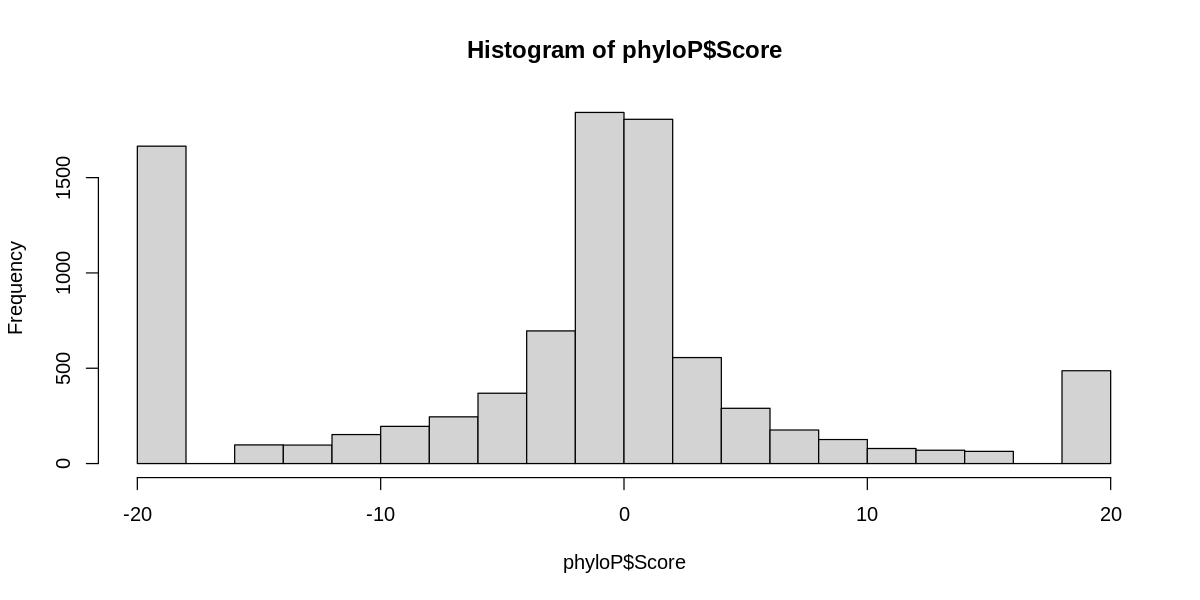

In [114]:
hist(phyloP$Score)

In [115]:
length(goi_acc)
length(goi_con)

[1] 2464

[1] 1007

In [116]:
cont_table(goi_acc,phyloP[,1],goi_more)
fisher.test(cont_table(goi_acc,phyloP[,1],goi_more),alternative = "greater")
# fisher.test(cont_table(goi_acc,phyloP[,1],goi_less))
# fisher.test(cont_table(goi_con,phyloP[,1],goi_more))
# fisher.test(cont_table(goi_con,phyloP[,1],goi_less))

15,2449
10,6539



	Fisher's Exact Test for Count Data

data:  cont_table(goi_acc, phyloP[, 1], goi_more)
p-value = 0.0006058
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 1.905553      Inf
sample estimates:
odds ratio 
  4.004345 


In [5]:
library(ggplot2)

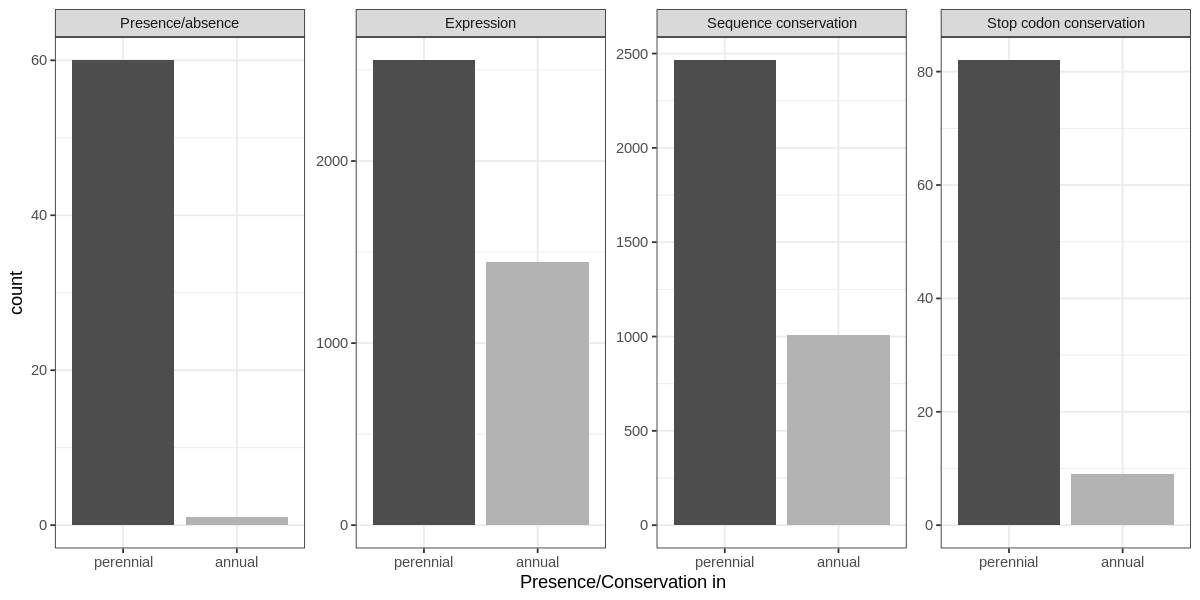

In [12]:
pData = data.frame(count = c(60,1,2553,1443,2464,1007,82,9),
                   test = factor(rep(c("Presence/absence","Expression","Sequence conservation","Stop codon conservation"),each = 2),
                                 levels = c("Presence/absence","Expression","Sequence conservation","Stop codon conservation")),
                   class = factor(rep(c("perennial","annual"),4),levels = c("perennial","annual")))
options(repr.plot.width=10, repr.plot.height=5)
ggplot(pData, aes(fill=class, y=count, x=class)) + 
    geom_bar(position="dodge", stat="identity") +
    facet_wrap(~test,scales = 'free',nrow = 1) +
    scale_fill_grey(start = .3,end = .7) +
    theme_bw() +
    theme(legend.position = "none") +
    xlab("Presence/Conservation in")
# barplot(matrix(c(144,12,1782,1572,91,9),2,3),beside = T)

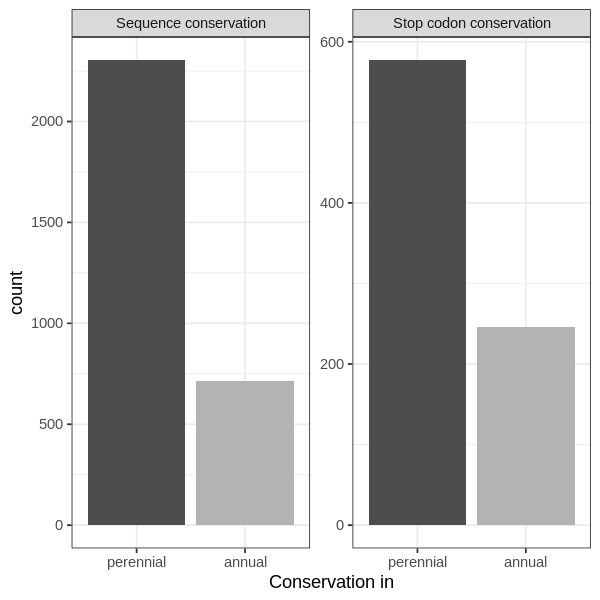

In [69]:
pData2 = data.frame(count = c(2303,713,577,246),
                   test = factor(rep(c("Sequence conservation","Stop codon conservation"),each = 2),
                                 levels = c("Sequence conservation","Stop codon conservation")),
                   class = factor(rep(c("perennial","annual"),4),levels = c("perennial","annual")))
options(repr.plot.width=5, repr.plot.height=5)
ggplot(pData2, aes(fill=class, y=count, x=class)) + 
    geom_bar(position="dodge", stat="identity") +
    facet_wrap(~test,scales = 'free',nrow = 1) +
    scale_fill_grey(start = .3,end = .7) +
    theme_bw() +
    theme(legend.position = "none") +
    xlab("Conservation in")
# barplot(matrix(c(144,12,1782,1572,91,9),2,3),beside = T)

In [15]:
# dir.create("/workdir/sh2246/p_panAndOGASR/output/fig")
png("/workdir/sh2246/p_panAndOGASR/output/fig/FigB_v2.png",width = 8.7*1.5,height = 8.7,units = "cm",res = 600,pointsize = 8)
ggplot(pData, aes(fill=class, y=count, x=class)) + 
    geom_bar(position="dodge", stat="identity") +
    facet_wrap(~test,scales = 'free',nrow = 1) +
    scale_fill_grey(start = .3,end = .7) +
    theme_bw() +
    theme(legend.position = "none",axis.text = element_text(size = 6),axis.title = element_text(size = 8),strip.text = element_text(size = 5)) +
    xlab("Presence/Conservation in") +
    ylab("Orthogroup counts")
dev.off()

png 
  2

In [70]:
# dir.create("/workdir/sh2246/p_panAndOGASR/output/fig")
png("/workdir/sh2246/p_panAndOGASR/output/fig/FigB_v3.png",width = 8.7*1.5,height = 8.7,units = "cm",res = 600,pointsize = 8)
ggplot(pData2, aes(fill=class, y=count, x=class)) + 
    geom_bar(position="dodge", stat="identity") +
    facet_wrap(~test,scales = 'free',nrow = 1) +
    scale_fill_grey(start = .3,end = .7) +
    theme_bw() +
    theme(legend.position = "none",axis.text = element_text(size = 6),axis.title = element_text(size = 8),strip.text = element_text(size = 5)) +
    xlab("Conservation in") +
    ylab("Syntenic gene counts")
dev.off()

png 
  2

In [34]:
library(ggplot2)

In [159]:
cont_table(goi_acc,phyloP[,1],goi_more)
cont_table(goi_con,phyloP[,1],goi_less)

10,1711
15,7913


0,1306
1,8342


In [72]:
pav_goi = read.csv("/workdir/sh2246/p_panAndOGASR/output/OG_4-8annual17perennial.csv")[,1]

In [73]:
head(pav_goi)
head(names(aln.list)[FET.p<0.05&FET.or>1])

[1] "OG0002200" "OG0002236" "OG0002272" "OG0002294" "OG0002313" "OG0002401"

[1] "OG0000234" "OG0000253" "OG0000368" "OG0000459" "OG0000471" "OG0000522"

In [76]:
test = cont_table(pav_goi,names(aln.list),names(aln.list)[p.adjust(FET.p,"BH")<0.05&FET.or>1])
test
fisher.test(test,alternative = "greater")
chisq.test(test)

11,580
244,20216



	Fisher's Exact Test for Count Data

data:  test
p-value = 0.1058
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.8664824       Inf
sample estimates:
odds ratio 
  1.571277 



	Pearson's Chi-squared test with Yates' continuity correction

data:  test
X-squared = 1.6239, df = 1, p-value = 0.2026


In [95]:
# miniProt CDS MSA
aln.flist = list.files("/workdir/sh2246/p_panAndOGASR/output/CDSMSAPerOG_v3",full.names = T,
                       pattern = "*.gs.l0.fa$")
aln.list = mclapply(aln.flist,readDNAStringSet,mc.cores = 20)
names(aln.list) = gsub(".gs.l0.fa","",strsplit2(aln.flist,"/")[,7])

cont_tab_list = mclapply(aln.list,function(a){
    codonArray = sapply(a,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))
                        
    stopSite = unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)))
    if (any(stopSite<nrow(codonArray)*0.9)){idx = names(which(stopSite<nrow(codonArray)*0.9))
    } else idx = NULL

    annualPattern = "Zm-|Zh-|Zl-|Zn-|Zv-|Zx-|Ir-|Sb-|Te-"
    cont_tab = cbind(table(grepl(annualPattern,idx))[c("TRUE","FALSE")],
                     table(grepl(annualPattern,setdiff(colnames(codonArray),idx)))[c("TRUE","FALSE")])
    colnames(cont_tab) = c("TRUE","FALSE")
    rownames(cont_tab) = c("annual","perennial")
    cont_tab[is.na(cont_tab)] = 0
    return(cont_tab)                               
},mc.cores = 20)

In [96]:
# Premature stop
pmStop_list = mclapply(aln.list,function(a){
    codonArray = sapply(a,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))
                        
    stopSite = unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)))
    if (any(stopSite<nrow(codonArray)*0.9)){idx = names(which(stopSite<nrow(codonArray)*0.9))
    } else idx = NULL

    return(idx)                               
},mc.cores = 20)

In [97]:
FET.p = mclapply(cont_tab_list,function(x) fisher.test(x)$p.value,mc.cores = 20)
FET.or = mclapply(cont_tab_list,function(x) fisher.test(x)$estimate,mc.cores = 20)                 

sum(p.adjust(FET.p,"BH")<0.05&FET.or>1)
sum(p.adjust(FET.p,"BH")<0.05&FET.or<1)
goi_more = names(which(p.adjust(FET.p,"BH")<0.05&FET.or>1))
goi_less = names(which(p.adjust(FET.p,"BH")<0.05&FET.or<1))

[1] 378

[1] 19

In [99]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),names(FET.p))
# background = intersect(names(GODB),paste0(names(diffP),".1"))

tmp=factor(as.integer(background%in%goi_more))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_more=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)

tmp=factor(as.integer(background%in%goi_less))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_less=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


Building most specific GOs .....

	( 1095 GO terms found. )


Build GO DAG topology ..........

	( 2605 GO terms and 5372 relations. )


Annotating nodes ...............

	( 10935 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 310 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 310 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 13:	2 nodes to be scored	(0 eliminated genes)


	 Level 12:	5 nodes to be scored	(0 eliminated genes)


	 Level 11:	9 nodes to be scored	(72 eliminated genes)


	 Level 10:	16 nodes to be scored	(132 eliminated genes)


	 Level 9:	29 nodes to be scored	(1379 eliminated genes)


	 Level 8:	31 nodes to be scored	(1905 eliminated genes)


	 Level 7:	35 nodes to be scored	(2279 eliminated genes)


	 Level 6:	51 nodes to be scored	(4710 eliminated genes)


	 Level 5:	58 nodes to be scored	(5847 eliminated genes)


	 Level 4:

In [101]:
head(GO_res_table_more,10)
head(GO_res_table_less,10)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0006952,defense response,604,23,5.85,2,1.2e-08,1.2e-08
2,GO:0016104,triterpenoid biosynthetic process,25,6,0.24,3,1.1e-07,1.1e-07
3,GO:0016973,poly(A)+ mRNA export from nucleus,5,2,0.05,13,0.00091,0.00091
4,GO:0045005,DNA-templated DNA replication maintenance of fidelity,5,2,0.05,14,0.00091,0.00091
5,GO:0016567,protein ubiquitination,260,9,2.52,15,0.00093,0.00277
6,GO:0016575,histone deacetylation,12,2,0.12,19,0.00577,0.00577
7,GO:0006298,mismatch repair,14,2,0.14,25,0.00785,0.00785
8,GO:0006284,base-excision repair,22,2,0.21,32,0.01895,0.01895
9,GO:0070534,protein K63-linked ubiquitination,5,1,0.05,37,0.04755,0.04755


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0000723,telomere maintenance,28,1,0.00,1,0.0026,0.0026
2,GO:0006281,DNA repair,212,1,0.02,4,0.0194,0.0194
3,GO:0006139,nucleobase-containing compound metabolic process,2535,1,0.23,15,0.2318,1.0000
4,GO:0006259,DNA metabolic process,323,1,0.03,7,0.0295,1.0000
5,GO:0006725,cellular aromatic compound metabolic process,2696,1,0.25,17,0.2465,1.0000
6,GO:0006807,nitrogen compound metabolic process,5970,1,0.55,22,0.5460,1.0000
7,GO:0006950,response to stress,1089,1,0.10,12,0.0996,1.0000
8,GO:0006974,cellular response to DNA damage stimulus,220,1,0.02,5,0.0201,1.0000
9,GO:0006996,organelle organization,420,1,0.04,8,0.0384,1.0000


In [66]:
background2 = paste0(phyloP[,1],".1")
tmp=factor(as.integer(background2%in%paste0(intersect(goi_more,goi_acc),".1")))
names(tmp)=background2
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table3=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)


Building most specific GOs .....

	( 469 GO terms found. )


Build GO DAG topology ..........

	( 1574 GO terms and 3209 relations. )


Annotating nodes ...............

	( 1212 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 164 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 164 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 11:	1 nodes to be scored	(0 eliminated genes)


	 Level 10:	5 nodes to be scored	(0 eliminated genes)


	 Level 9:	10 nodes to be scored	(204 eliminated genes)


	 Level 8:	12 nodes to be scored	(245 eliminated genes)


	 Level 7:	15 nodes to be scored	(282 eliminated genes)


	 Level 6:	27 nodes to be scored	(359 eliminated genes)


	 Level 5:	40 nodes to be scored	(605 eliminated genes)


	 Level 4:	27 nodes to be scored	(779 eliminated genes)


	 Level 3:	19 nodes to be scored	(884 eliminated genes)


	 Level 2:	7 node

In [70]:
head(GO_res_table3,10)
head(GO_res_table3[order(GO_res_table3$`Rank in Fisher.classic`),],10)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0006511,ubiquitin-dependent protein catabolic process,20,2,0.38,10,0.0532,0.053
2,GO:0006284,base-excision repair,5,1,0.09,19,0.0915,0.091
3,GO:0006887,exocytosis,5,1,0.09,20,0.0915,0.091
4,GO:0009066,aspartate family amino acid metabolic process,5,1,0.09,21,0.0915,0.091
5,GO:0009873,ethylene-activated signaling pathway,5,1,0.09,22,0.0915,0.091
6,GO:0044772,mitotic cell cycle phase transition,5,1,0.09,23,0.0915,0.091
7,GO:0000070,mitotic sister chromatid segregation,6,1,0.11,29,0.1088,0.109
8,GO:0046351,disaccharide biosynthetic process,6,1,0.11,30,0.1088,0.109
9,GO:0009664,plant-type cell wall organization,7,1,0.13,35,0.1258,0.126


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
150,GO:0090304,nucleic acid metabolic process,299,12,5.67,1,0.0038,1.000
69,GO:0016070,RNA metabolic process,276,11,5.24,2,0.0067,1.000
32,GO:0006139,nucleobase-containing compound metabolic process,340,12,6.45,3,0.0117,1.000
119,GO:0046483,heterocycle metabolic process,352,12,6.68,4,0.0157,1.000
155,GO:1901360,organic cyclic compound metabolic process,355,12,6.74,5,0.0168,1.000
37,GO:0006725,cellular aromatic compound metabolic process,356,12,6.76,6,0.0172,1.000
93,GO:0034641,cellular nitrogen compound metabolic process,395,12,7.50,7,0.0392,1.000
63,GO:0010467,gene expression,309,10,5.86,8,0.0446,1.000
19,GO:0006396,RNA processing,43,3,0.82,9,0.0449,0.209


In [71]:
intersect(goi_less,goi_con)

[1] "Pavag01G050600" "Pavag02G305800" "Pavag02G355700" "Pavag03G175500"
[5] "Pavag04G207700" "Pavag04G273500" "Pavag05G009700" "Pavag07G171300"

In [72]:
cont_tab_list[["Pavag01G062400"]]
cont_tab_list[["Pavag02G199600"]]
cont_tab_list[["Pavag03G038800"]]
cont_tab_list[["Pavag04G192400"]]

,TRUE,FALSE
annual,1,19
perennial,1,84


,TRUE,FALSE
annual,1,19
perennial,5,74


,TRUE,FALSE
annual,0,19
perennial,6,83


,TRUE,FALSE
annual,0,19
perennial,1,66


In [109]:
test = aln.list[[1]]

In [111]:
codonArray = sapply(test,function(x) substring(as.character(x),seq(1,nchar(x),3),seq(3,nchar(x),3)))

idx = names(which(unlist(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)))<nrow(codonArray)*0.9))

annualPattern = "Zm|Zh|Zl|Zn|Zv|Zx|Ir|Sobic|Te"
cont_tab = cbind(table(grepl(annualPattern,idx))[c("TRUE","FALSE")],
                 table(grepl(annualPattern,setdiff(colnames(codonArray),idx)))[c("TRUE","FALSE")])
colnames(cont_tab) = c("TRUE","FALSE")
rownames(cont_tab) = c("annual","perennial")
cont_tab[is.na(cont_tab)] = 0

In [7]:
str(fisher.test(cont_tab_list[[1]]))

List of 7
 $ p.value    : num 1
 $ conf.int   : num [1:2] 0 17.4
  ..- attr(*, "conf.level")= num 0.95
 $ estimate   : Named num 0
  ..- attr(*, "names")= chr "odds ratio"
 $ null.value : Named num 1
  ..- attr(*, "names")= chr "odds ratio"
 $ alternative: chr "two.sided"
 $ method     : chr "Fisher's Exact Test for Count Data"
 $ data.name  : chr "cont_tab_list[[1]]"
 - attr(*, "class")= chr "htest"


In [115]:
na.omit(apply(codonArray,2,function(x) grep("TAA|TAG|TGA",x)[1]))

Ab00001aa000015_T001  Ab00001aa002096_T001  Ab00001aa032497_T001 
                   40                    40                    40 
 Ab00001aa036647_T001  Ab00001aa041405_T001  Ab00001aa004094_T001 
                   40                    40                    40 
 Ab00001aa062587_T001  Ab00001aa073311_T001  Ab00001aa088361_T001 
                   40                    40                    40 
 Ab00001aa014688_T001  Ac00001aa030129_T001  Ac00001aa036609_T001 
                  109                    40                    40 
 Ac00001aa037891_T001  Ac00001aa037948_T001  Ac00001aa041718_T001 
                   40                    40                    40 
 Ac00001aa070336_T001  Ac00001aa071436_T001  Ac00001aa077899_T001 
                   40                    40                    40 
 Ag00001aa001262_T001  Ag00001aa150015_T001  Ag00001aa151183_T001 
                   40                    64                    40 
 Ag00001aa155988_T001  Ag00001aa156609_T001  Ag00001aa051075_T001 
                   40                   109                    40 
 Ag00001aa070288_T001  Ag00001aa072716_T001  Ag00001aa088506_T001 
                   40                    40                    40 
 Ag00001aa120614_T001  Ag00001aa129036_T001  Ag00001aa134163_T001 
                   40                    40                    40 
 Av00001aa022094_T001  Av00001aa023036_T001  Av00001aa006513_T001 
                   40                    40                    40 
 Bl00001aa046385_T001  Bl00001aa007243_T001  Bl00001aa070042_T001 
                   40                    40                    40 
 Bl00001aa119270_T001  Bl00001aa126250_T001  Bl00001aa128389_T001 
                   40                    40                    40 
 Bl00001aa151607_T001  Bl00001aa153193_T001  Bl00001aa158290_T001 
                   40                    40                    40 
 Bl00001aa163090_T001  Bl00001aa037811_T001  Bl00001aa040543_T001 
                   40                    40                    40 
 Cc00001aa023554_T001  Cc00001aa049103_T001  Cc00001aa050993_T001 
                   40                    40                    40 
 Cc00001aa055264_T001  Cc00001aa055426_T001  Cc00001aa070527_T001 
                   40                    40                    40 
 Cc00001aa087105_T001  Cc00001aa091958_T001  Cc00001aa102317_T001 
                   40                    40                    40 
 Cc00001aa106380_T001  Cc00001aa123726_T001  Cr00001aa022761_T001 
                   40                    40                    38 
 Cr00001aa023179_T001  Cr00001aa032628_T001  Cr00001aa032633_T001 
                   40                    38                    38 
 Cr00001aa034580_T001  Cr00001aa040279_T001  Cr00001aa021177_T001 
                   32                    40                    40 
 Cr00001aa021944_T001  Cs00001aa001668_T001  Cs00001aa002686_T001 
                   38                    40                    40 
 Cs00001aa003366_T001  Cs00001aa026042_T001  Cs00001aa005823_T001 
                   40                    40                    40 
 Cs00001aa011558_T001  Cs00001aa012562_T001  Cs00001aa012633_T001 
                   40                    40                    40 
 Et00001aa046040_T001  Et00001aa005368_T001  Et00001aa050759_T001 
                   40                    40                    40 
 Et00001aa010051_T001  Et00001aa066106_T001  Et00001aa069964_T001 
                   64                    54                    64 
 Et00001aa072010_T001  Hp00001aa184514_T001  Hp00001aa184726_T001 
                   40                    40                    40 
 Hp00001aa140225_T001  Hp00001aa146661_T001  Hp00001aa148702_T001 
                   40                    40                    40 
 Hp00001aa167319_T001  Hc00001aa011385_T001  Hc00001aa011450_T001 
                   82                    40                    40 
 Ir00001aa017402_T001  Ir00001aa018811_T001  Ir00001aa002280_T002 
                   40                    40     